In [127]:
# Librerías
# ======================================================================================
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from io import StringIO
import contextlib
import re
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

# pmdarima
import pmdarima
from pmdarima import ARIMA
from pmdarima import auto_arima

# statsmodels
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('once')

color = '\033[1m\033[38;5;208m' 

In [128]:
ticker = 'NVDA'
accion = yf.Ticker(ticker)
data = accion.history(start = '2024-07-27', end = '2024-12-10', interval = '1d')
print(data.head())
print(data.tail())

                                 Open        High         Low       Close  \
Date                                                                        
2024-07-29 00:00:00-04:00  113.672443  116.262040  111.282813  111.572762   
2024-07-30 00:00:00-04:00  111.502772  111.972700  102.524163  103.713982   
2024-07-31 00:00:00-04:00  112.882564  118.321718  110.862872  117.001923   
2024-08-01 00:00:00-04:00  117.511853  120.141452  106.793507  109.193138   
2024-08-02 00:00:00-04:00  103.743973  108.703206  101.354343  107.253426   

                              Volume  Dividends  Stock Splits  
Date                                                           
2024-07-29 00:00:00-04:00  248152100        0.0           0.0  
2024-07-30 00:00:00-04:00  486833300        0.0           0.0  
2024-07-31 00:00:00-04:00  473174200        0.0           0.0  
2024-08-01 00:00:00-04:00  523462300        0.0           0.0  
2024-08-02 00:00:00-04:00  482027500        0.0           0.0  
            

In [129]:
precio = data['Close']
precio = precio.to_frame()
precio.index = precio.index.strftime('%Y-%m-%d')
precio.index = pd.to_datetime(precio.index)
precio.index.name = None

## Gráfico de los precios de la acción

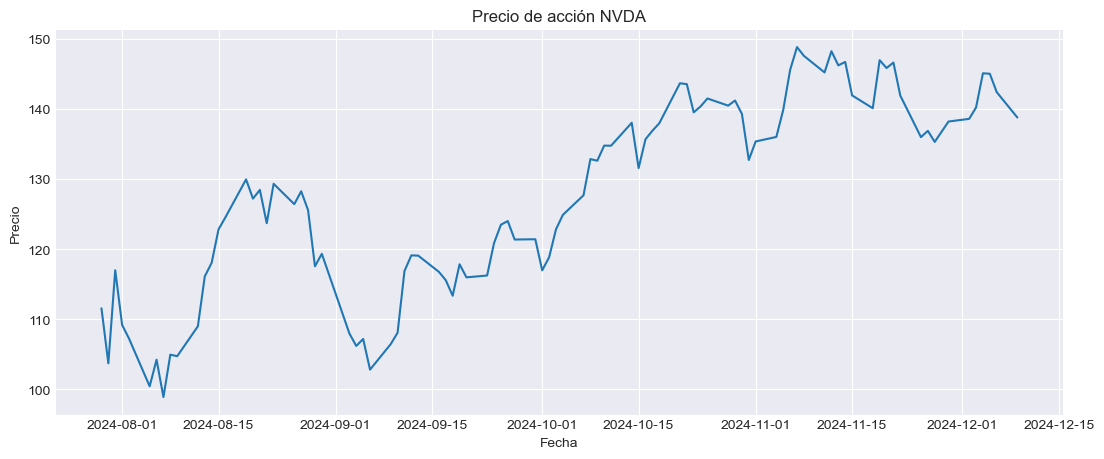

In [130]:
plt.figure(figsize = (13,5))
plt.plot(precio)
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.title(f'Precio de acción {ticker}')
plt.show()

## Método Rango - Media

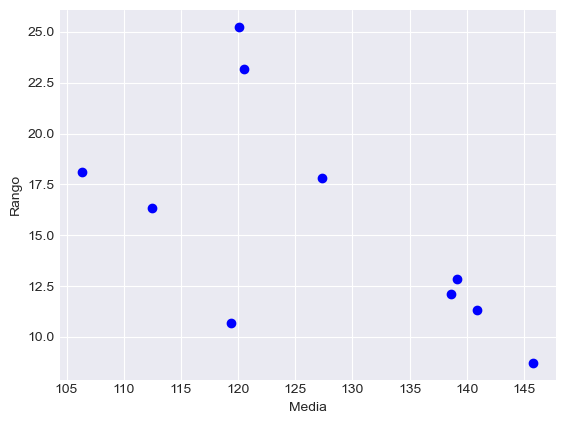

In [131]:
# Número máximo de observaciones
max_observations = len(precio)
# Establece el tamaño de cada grupo
group_size = 9

# Crea una serie con datos aleatorios
serie1 = pd.Series(precio["Close"])  # Datos aleatorios

# Genera automáticamente los rangos de grupos
num_groups = max_observations // group_size  # Calcula el número de grupos
group_ranges = [(i * group_size, (i + 1) * group_size) for i in range(num_groups)]

# Ajusta el último rango para incluir todas las observaciones si es necesario
if group_ranges[-1][1] < max_observations:
    group_ranges[-1] = (group_ranges[-1][0], max_observations)

# Inicializa listas para almacenar resultados
mumedia = []
murango = []

# Calcula la media y el rango para cada grupo
for start, end in group_ranges:
    group = serie1.iloc[start:end]
    mean_value = group.mean()
    max_value = group.max()
    min_value = group.min()
    range_value = max_value - min_value
    
    mumedia.append(mean_value)
    murango.append(range_value)

# Crea series para media y rango
media = pd.Series(mumedia)
rango = pd.Series(murango)

# Genera un gráfico de dispersión
plt.scatter(media, rango, label='Datos', color='blue')
plt.xlabel('Media')
plt.ylabel('Rango')
plt.show()

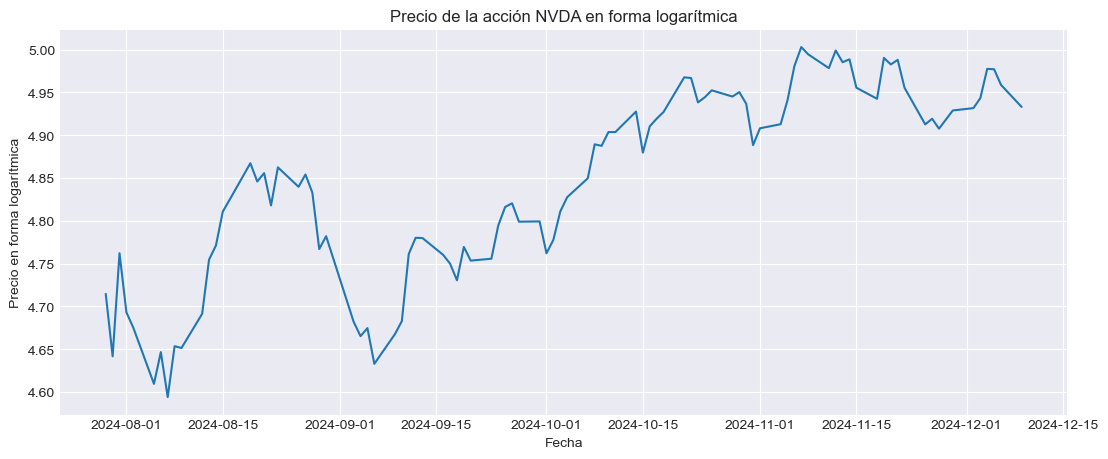

In [132]:
precio_log = np.log(precio)
plt.figure(figsize = (13,5))
plt.plot(precio_log)
plt.xlabel('Fecha')
plt.ylabel('Precio en forma logarítmica')
plt.title(f'Precio de la acción {ticker} en forma logarítmica')
plt.show()

## Histograma de los precios en forma logarítmica

<Axes: ylabel='Count'>

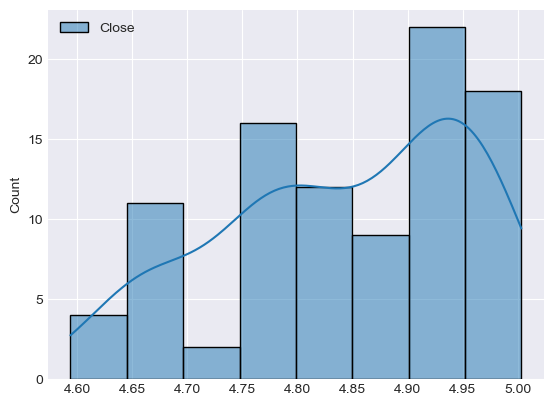

In [133]:
sns.histplot(precio_log, kde = True, color = 'red')

## Estimación - Modelo AUTOARIMA

In [134]:
modelo_auto_1 = pmdarima.auto_arima(precio_log, seasonal = None,
                                    stepwise = True, trace = True, with_intercept=False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=-371.453, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-361.334, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-362.234, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-361.175, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-369.243, Time=0.28 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-367.090, Time=0.21 sec
 ARIMA(3,1,2)(0,0,0)[0]             : AIC=-367.820, Time=0.51 sec
 ARIMA(2,1,3)(0,0,0)[0]             : AIC=-367.897, Time=0.49 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-364.927, Time=0.16 sec
 ARIMA(1,1,3)(0,0,0)[0]             : AIC=-369.721, Time=0.44 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=-368.318, Time=0.43 sec
 ARIMA(3,1,3)(0,0,0)[0]             : AIC=-367.657, Time=0.49 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-369.756, Time=0.50 sec

Best model:  ARIMA(2,1,2)(0,0,0)[0]          
Total fit time: 4.143 seconds


In [135]:
print(modelo_auto_1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   94
Model:               SARIMAX(2, 1, 2)   Log Likelihood                 190.727
Date:                Wed, 11 Dec 2024   AIC                           -371.453
Time:                        13:38:09   BIC                           -358.790
Sample:                             0   HQIC                          -366.340
                                 - 94                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3619      0.130     -2.779      0.005      -0.617      -0.107
ar.L2         -0.4740      0.154     -3.084      0.002      -0.775      -0.173
ma.L1          0.2398      0.094      2.550      0.0

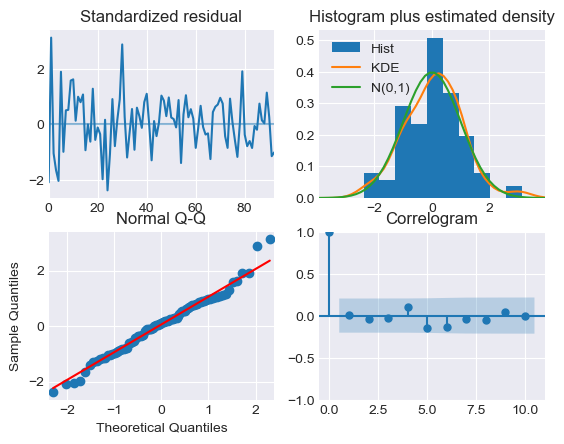

In [136]:
modelo_auto_1.plot_diagnostics()
plt.show()

### Chequeo - Conclusiones
- Análisis de coeficientes: Todos los coeficientes son significativos (p-value < 0.05).
- Análisis de residuos:
    - Correlograma de residuos -> Todos los picos están dentro del intervalo de confianza.
    - La prueba de Normalidad se cumple ya que el p-value generado por el Jarque - Bera es mayor a 0.05.
    - El p-value del estadístico Ljung-Box al ser también mayor a 0.05, se concluye que el modelo es adecuado.
    - Asimismo, la gráfica de los residuos está totalmente centrada en cero y el gráfico Normal Q - Q señala que sí se dibuja una distribución normal.

## Predicción: Puntual e Interválica

In [137]:
n_periodos = 12
pronostico_log, int_conf_log = modelo_auto_1.predict(n_periods=n_periodos, return_conf_int=True)
pronostico_antilog = np.exp(pronostico_log)
int_conf_antilog = np.exp(int_conf_log)

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [138]:
ultima_fecha = precio.index[-1]
fechas_pronosticadas = pd.date_range(start=ultima_fecha, periods=n_periodos + 1, freq='D')[1:]

In [139]:
pronostico_antilog.index = fechas_pronosticadas

In [140]:
pronostico_antilog = pronostico_antilog.to_frame()

In [141]:
pronostico_antilog.rename(columns = {0:'Precio_Pronosticado'}, inplace = True)

In [142]:
ultimo_precio = precio.tail(1)
ultimo_precio.rename(columns = {'Close':'Precio_Pronosticado'}, inplace = True)
precios_estimados_antilog = pd.concat([ultimo_precio,pronostico_antilog])

C:\Users\HP\AppData\Local\Temp\ipykernel_5612\3889338776.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ultimo_precio.rename(columns = {'Close':'Precio_Pronosticado'}, inplace = True)


In [143]:
precios_estimados_antilog

,Precio_Pronosticado
2024-12-09,138.809998
2024-12-10,135.972469
2024-12-11,134.921782
2024-12-12,136.632165
2024-12-13,136.511783
2024-12-14,135.742359
2024-12-15,136.077129
2024-12-16,136.320640
2024-12-17,136.073502
2024-12-18,136.047533


In [144]:
inter_conf_antilog = pd.DataFrame(int_conf_antilog, columns = ['Lim_Inf', 'Lim_Sup'], index = pronostico_antilog.index)

In [145]:
precio_inter_conf = pd.DataFrame(columns = ['Lim_Inf', 'Lim_Sup'], index = ultimo_precio.index)

In [146]:
precio_inter_conf['Lim_Inf'] = ultimo_precio
precio_inter_conf['Lim_Sup'] = ultimo_precio
precio_inter_conf

,Lim_Inf,Lim_Sup
2024-12-09,138.809998,138.809998


In [147]:
inter_conf_antilog = pd.concat([precio_inter_conf, inter_conf_antilog])

In [148]:
inter_conf_antilog

,Lim_Inf,Lim_Sup
2024-12-09,138.809998,138.809998
2024-12-10,127.991945,144.450594
2024-12-11,124.487783,146.230311
2024-12-12,121.931483,153.105237
2024-12-13,119.175092,156.370485
2024-12-14,116.846917,157.693405
2024-12-15,115.313410,160.579632
2024-12-16,113.762465,163.351919
2024-12-17,112.134507,165.123106
2024-12-18,110.783570,167.072891


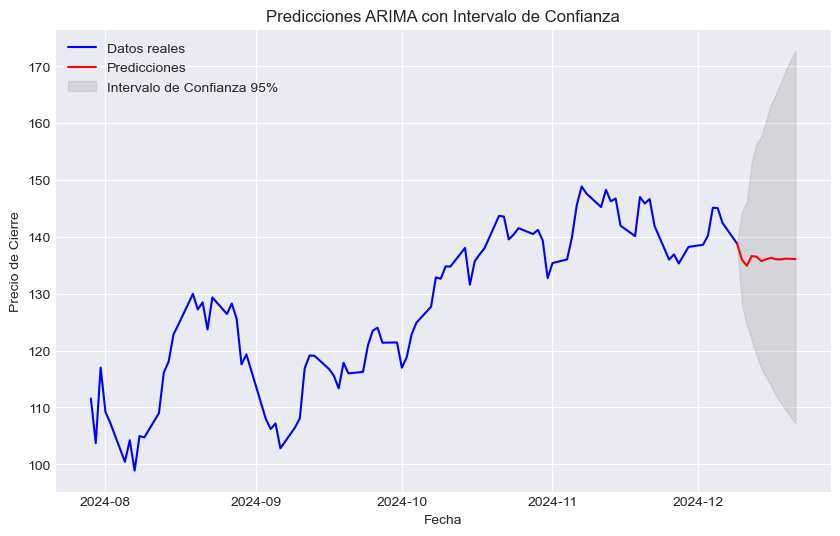

In [149]:
plt.figure(figsize=(10, 6))

# Graficar los datos reales
plt.plot(precio['Close'], label='Datos reales', color='blue')

# Graficar las predicciones
plt.plot(precios_estimados_antilog['Precio_Pronosticado'], label='Predicciones', color='red')

# Graficar el intervalo de confianza (zona sombreada)
plt.fill_between(inter_conf_antilog.index, inter_conf_antilog['Lim_Inf'], inter_conf_antilog['Lim_Sup'], color='gray', alpha=0.2, label='Intervalo de Confianza 95%')

# Títulos y leyenda
plt.title('Predicciones ARIMA con Intervalo de Confianza')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.legend(loc = 'upper left')

# Mostrar la gráfica
plt.show()